# LLM calls: inputs and outputs

A readable view of saved narration runs: what each customer's payload sent to
the model, what came back, whether the guards accepted it, and what it cost.

**This notebook makes no API calls and costs nothing.** It only reads result
files that a live run already saved to `outputs/`. Re-run it as often as you
like.

To create a results file (this *does* spend money; check the budget first):

```bash
NARRATE_RESULTS=outputs/<name>.json uv run --env-file .env pytest tests/test_narrate_live.py -m live -v -s
```

The live test saves the 8 sampled customers. Its 2 determinism-check calls are
not saved, so they don't appear here.

Needs the `notebook` dependency group for the plots: `uv sync --group notebook`.

In [1]:
import html
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

import narrate  # only for rejection_rates(): computed once, not re-implemented here

OUTPUTS = Path("outputs")
PROMPTS = Path("prompts")

# gpt-4o-mini list prices, USD per million tokens. An estimate: check the
# current price list before quoting these numbers anywhere.
PRICE_PER_M = {"gpt-4o-mini": {"in": 0.15, "out": 0.60}}

available = sorted(OUTPUTS.glob("*.json"))
print("Result files in outputs/:")
for path in available:
    print("  ", path.name)

Result files in outputs/:
   stage1_v2.json


## Choose a run

Set `RESULTS_FILE` to the file you want to read. It defaults to the newest one.

In [2]:
RESULTS_FILE = max(available, key=lambda p: p.stat().st_mtime)  # or OUTPUTS / "stage1_v2.json"

results = json.loads(Path(RESULTS_FILE).read_text())
print(f"{RESULTS_FILE}: {len(results)} customers")

outputs/stage1_v2.json: 8 customers


## 1. Run overview

In [3]:
def cost_usd(model, tokens_in, tokens_out):
    price = PRICE_PER_M.get(model)
    if price is None:
        return None
    return (tokens_in * price["in"] + tokens_out * price["out"]) / 1_000_000


attempts = [a for r in results for a in r["attempts"]]
tokens_in = sum(a["prompt_tokens"] or 0 for a in attempts)
tokens_out = sum(a["completion_tokens"] or 0 for a in attempts)
models = sorted({r["model"] for r in results})
rates = narrate.rejection_rates(results)

overview = pd.Series({
    "file": Path(RESULTS_FILE).name,
    "prompt version(s)": ", ".join(sorted({r["prompt_version"] for r in results})),
    "model(s)": ", ".join(models),
    "customers": len(results),
    "API calls saved": len(attempts),
    "retries issued": rates["retries_issued"],
    "first-attempt rejection rate": rates["first_attempt_rejection_rate"],
    "final rejection rate": rates["final_rejection_rate"],
    "tokens in / out": f"{tokens_in:,} / {tokens_out:,}",
    "avg tokens per call (in / out)": f"{tokens_in / len(attempts):.0f} / {tokens_out / len(attempts):.0f}",
    "estimated cost (USD)": (
        f"${cost_usd(models[0], tokens_in, tokens_out):.4f}" if len(models) == 1 else "mixed models"
    ),
}, name="value")
overview.to_frame()

,value
file,stage1_v2.json
prompt version(s),explanation_v2
model(s),gpt-4o-mini
customers,8
API calls saved,8
retries issued,0
first-attempt rejection rate,0.0
final rejection rate,0.0
tokens in / out,"5,048 / 742"
avg tokens per call (in / out),631 / 93


In [4]:
print("First-attempt rejections by type: ", rates["first_attempt_by_type"] or "none")
print("Second-attempt rejections by type:", rates["second_attempt_by_type"] or "none")

First-attempt rejections by type:  none
Second-attempt rejections by type: none


## 2. The system prompt used

Loaded from `prompts/<prompt_version>.txt`. This is the exact text sent as the
system message; the tests pin each file's sha256, so it can't have changed
since the run.

In [5]:
for version in sorted({r["prompt_version"] for r in results}):
    display(Markdown(f"**`prompts/{version}.txt`**"))
    print((PROMPTS / f"{version}.txt").read_text())

**`prompts/explanation_v2.txt`**

You explain a churn model's decision to a retention manager who will act on
what you write. You did not calculate anything, and you must not add anything.

You will be given:
- risk_level: low, moderate, high or very high.
- decision: what was decided for this customer.
- factors: up to three, strongest first. Each has a plain-English name, a
  field id and a direction (raises risk or lowers risk). Some also have this
  customer's value, and how that value compares to a typical customer.

Reply with a JSON object with exactly these keys:
- "risk_level": the risk_level you were given, copied exactly.
- "reasons": one entry per factor you explain, strongest first. Each entry is
  {"field": the factor's field id, "direction": the factor's direction}, both
  copied exactly.
- "summary": one or two sentences for the manager.

Rules for the summary:
- Mention only the listed factors. Never add a factor, however plausible it
  sounds for a telecom customer.
- If you call a value high, low, lo

## 3. Customer by customer

Each card shows the input on the left (exactly what the model was sent: the
risk level, the decision and the factors) and the output on the right (the
accepted JSON, laid out). Below it are every attempt's raw reply and verdict.

In the reasons table, ✓ means the reason's field and direction match the
payload. Anything else would have been rejected by the guards, so an accepted
output should show only ✓.

Customer numbers are positions in the file. For the live test they are rows
0–7 of `simulated_new_customers.csv`.

In [6]:
CARD_CSS = """
<style>
.llm-card { border: 1px solid #8884; border-radius: 10px; padding: 14px 16px; margin: 14px 0; }
.llm-card h3 { margin: 0 0 4px; }
.llm-meta { opacity: .75; font-size: .9em; margin-bottom: 10px; }
.llm-cols { display: flex; flex-wrap: wrap; gap: 18px; }
.llm-col { flex: 1 1 340px; min-width: 0; }
.llm-col h4 { margin: 6px 0; font-size: .8em; text-transform: uppercase; letter-spacing: .06em; opacity: .7; }
.llm-card table { border-collapse: collapse; width: 100%; font-size: .9em; }
.llm-card th, .llm-card td { text-align: left; padding: 3px 8px 3px 0; border-bottom: 1px solid #8883; vertical-align: top; }
.llm-summary { font-size: 1.02em; line-height: 1.5; padding: 8px 10px; border-left: 3px solid #3b9; background: #3b91; margin-top: 8px; }
.llm-attempt { font-size: .85em; margin-top: 8px; }
.llm-attempt pre { white-space: pre-wrap; word-break: break-word; margin: 4px 0 0; padding: 6px 8px; background: #8881; border-radius: 6px; }
.ok { color: #1a9a5a; font-weight: 600; }
.bad { color: #d0443a; font-weight: 600; }
</style>
"""
display(HTML(CARD_CSS))


def esc(value):
    return html.escape("" if value is None else str(value))


def factor_rows(factors):
    rows = "".join(
        f"<tr><td><b>{esc(f['name'])}</b><br><code>{esc(f['field'])}</code></td>"
        f"<td>{esc(f.get('value', '—'))}</td>"
        f"<td>{esc(f.get('vs_other_customers', f.get('compared_to_typical', '—')))}</td>"
        f"<td>{esc(f['direction'])}</td></tr>"
        for f in factors
    )
    return ("<table><tr><th>factor</th><th>value</th><th>vs other customers</th>"
            f"<th>direction</th></tr>{rows}</table>")


def reason_rows(structured, payload):
    expected = {f["field"]: f["direction"] for f in payload["factors"]}
    rows = ""
    for reason in structured["reasons"]:
        good = expected.get(reason["field"]) == reason["direction"]
        mark = '<span class="ok">✓</span>' if good else '<span class="bad">✗</span>'
        rows += (f"<tr><td><code>{esc(reason['field'])}</code></td>"
                 f"<td>{esc(reason['direction'])}</td><td>{mark}</td></tr>")
    return f"<table><tr><th>field</th><th>direction</th><th></th></tr>{rows}</table>"


def attempt_block(attempt):
    verdict = ('<span class="ok">accepted</span>' if attempt["accepted"]
               else f'<span class="bad">rejected: {esc(attempt["rejection_type"])}</span>'
                    f' — {esc(attempt["rejection_detail"])}')
    return (f'<div class="llm-attempt">Attempt {attempt["attempt"]}: {verdict} · '
            f'{attempt["prompt_tokens"]} in / {attempt["completion_tokens"]} out tokens · '
            f'{attempt["latency_ms"]:.0f} ms · finish: {esc(attempt.get("finish_reason"))}'
            f'<pre>{esc(attempt["text"])}</pre></div>')


def customer_card(i):
    r = results[i]
    payload = r["payload"]
    structured = r["structured"]
    if structured is not None:
        output = (f"<p>risk level: <b>{esc(structured['risk_level'])}</b></p>"
                  f"{reason_rows(structured, payload)}"
                  f'<div class="llm-summary">{esc(structured["summary"])}</div>'
                  f'<div class="llm-meta">{len(structured["summary"].split())} words</div>')
    else:
        output = (f'<p class="bad">No narrative: {esc(r["final_rejection_type"])}</p>')
    omitted = ", ".join(payload["protected_drivers_omitted"]) or "none"
    return f"""
    <div class="llm-card">
      <h3>Customer #{i}</h3>
      <div class="llm-meta">churn probability {r['churn_probability']:.4f} (not sent to the model) ·
        prompt {esc(r['prompt_version'])} · {esc(r['model'])} ·
        protected drivers withheld: {esc(omitted)}</div>
      <div class="llm-cols">
        <div class="llm-col"><h4>Input: sent to the model</h4>
          <p>risk level: <b>{esc(payload['risk_level'])}</b> · decision: <b>{esc(payload['decision'])}</b></p>
          {factor_rows(payload['factors'])}
        </div>
        <div class="llm-col"><h4>Output: accepted reply</h4>{output}</div>
      </div>
      {''.join(attempt_block(a) for a in r['attempts'])}
    </div>"""


for i in range(len(results)):
    display(HTML(customer_card(i)))

## 4. All summaries in one table

For scanning and comparing. Columns are wrapped; widen the notebook if needed.

In [7]:
table = pd.DataFrame([
    {
        "#": i,
        "probability": round(r["churn_probability"], 3),
        "risk level": r["payload"]["risk_level"],
        "decision": r["payload"]["decision"],
        "factors sent": ", ".join(f["field"] for f in r["payload"]["factors"]),
        "summary": r["narrative"] if r["narrative"] else f"(none: {r['final_rejection_type']})",
        "words": len(r["narrative"].split()) if r["narrative"] else 0,
        "attempts": len(r["attempts"]),
    }
    for i, r in enumerate(results)
]).set_index("#")

(table.style
    .set_properties(subset=["summary"], **{"white-space": "normal", "min-width": "380px", "text-align": "left"})
    .set_properties(subset=["factors sent"], **{"white-space": "normal", "min-width": "160px"}))

,probability,risk level,decision,factors sent,summary,words,attempts
#,,,,,,,
0,0.615000,high,target for retention,"contract, average_monthly_charges, internetservice","This customer is at high risk due to their month-to-month contract, well above typical average monthly charges, and fiber optic internet service. Targeting them for retention is a suitable decision.",30,1
1,0.070000,low,do not target,"contract, internetservice, onlinesecurity","This customer has a one-year contract, uses DSL for internet service, and has an online security add-on. These factors contribute to their low risk level, supporting the decision to not target them.",32,1
2,0.055000,low,do not target,"contract, contractvstenure, tenure","This customer has a two-year contract, a contract length well above typical compared to their tenure, and has been a customer for 72 months, which is also well above typical. Therefore, the decision to not target them is appropriate given their low risk level.",44,1
3,0.355000,moderate,do not target,"contract, internetservice, multiplelines","This customer has a month-to-month contract, which raises their risk. However, they use DSL for internet service and do not have multiple phone lines, both of which lower their risk. Therefore, the decision to not target them is appropriate.",39,1
4,0.367000,moderate,do not target,"contract, average_monthly_charges, monthlycharges","This customer has a one-year contract, which lowers their risk. However, both their average monthly bill and current monthly bill are well above typical, contributing to a moderate risk level. Therefore, the decision to not target them is appropriate.",39,1
5,0.316000,moderate,do not target,"contract, contractvstenure, tenure","This customer has a month-to-month contract, which raises their risk. Additionally, their contract length relative to tenure and their short time as a customer are both below typical, contributing to the moderate risk level. Therefore, the decision to not target them is appropriate.",43,1
6,0.824000,very high,target for retention,"contract, contractvstenure, tenure","This customer has a month-to-month contract, which raises their risk. Additionally, their contract length compared to tenure is below typical, and they have only been a customer for 1 month, which is well below typical.",35,1
7,0.085000,low,do not target,"contract, contractvstenure, tenure","This customer has a one-year contract, a contract length well above typical compared to their tenure, and has been with us for 68 months, which is also well above typical. Therefore, I agree with the decision to not target them.",40,1


## 5. Tokens, latency and length

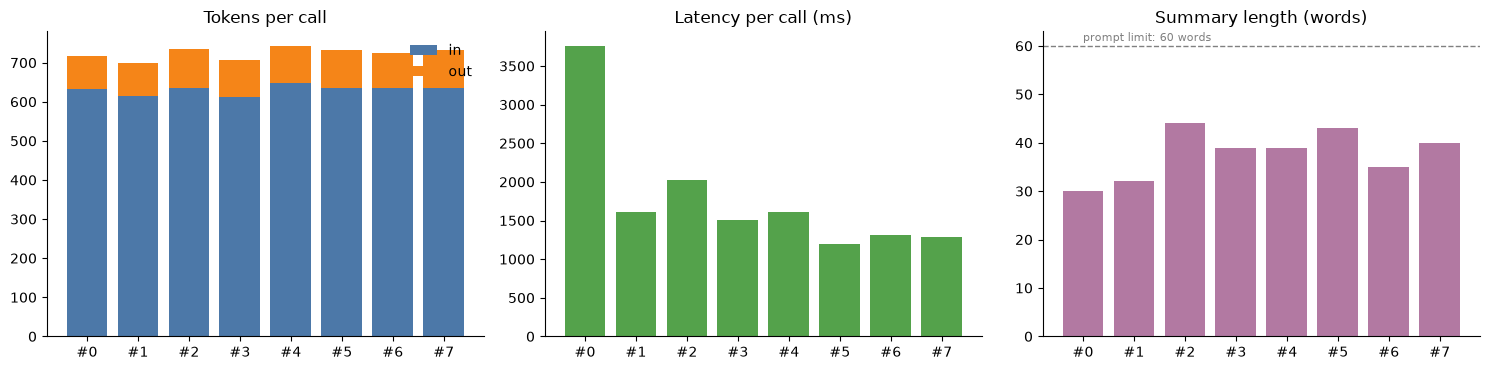

,tokens in,tokens out,latency (ms)
mean,631.0,93.0,1788.0
min,613.0,83.0,1199.0
max,648.0,100.0,3761.0


In [8]:
calls = pd.DataFrame([
    {
        "customer": i,
        "attempt": a["attempt"],
        "tokens in": a["prompt_tokens"],
        "tokens out": a["completion_tokens"],
        "latency (ms)": a["latency_ms"],
        "accepted": a["accepted"],
    }
    for i, r in enumerate(results) for a in r["attempts"]
])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
labels = [f"#{c}" + (f"·{a}" if a > 1 else "") for c, a in zip(calls["customer"], calls["attempt"])]

axes[0].bar(labels, calls["tokens in"], color="#4c78a8", label="in")
axes[0].bar(labels, calls["tokens out"], bottom=calls["tokens in"], color="#f58518", label="out")
axes[0].set_title("Tokens per call")
axes[0].legend(frameon=False)

axes[1].bar(labels, calls["latency (ms)"], color="#54a24b")
axes[1].set_title("Latency per call (ms)")

words = [len(r["narrative"].split()) if r["narrative"] else 0 for r in results]
axes[2].bar([f"#{i}" for i in range(len(results))], words, color="#b279a2")
axes[2].axhline(60, color="grey", linestyle="--", linewidth=1)
axes[2].text(0, 61, "prompt limit: 60 words", fontsize=8, color="grey")
axes[2].set_title("Summary length (words)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

calls.describe().loc[["mean", "min", "max"], ["tokens in", "tokens out", "latency (ms)"]].round(0)

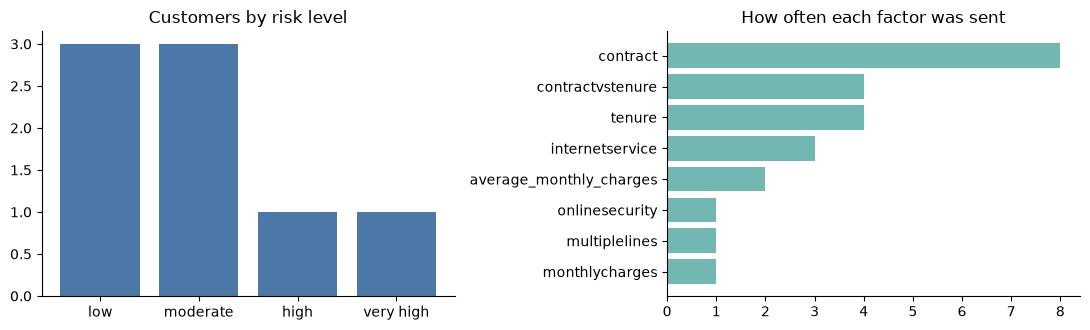

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

risk_order = ["low", "moderate", "high", "very high"]
risk_counts = Counter(r["payload"]["risk_level"] for r in results)
axes[0].bar(risk_order, [risk_counts.get(k, 0) for k in risk_order], color="#4c78a8")
axes[0].set_title("Customers by risk level")

field_counts = Counter(f["field"] for r in results for f in r["payload"]["factors"])
fields, counts = zip(*field_counts.most_common())
axes[1].barh(fields[::-1], counts[::-1], color="#72b7b2")
axes[1].set_title("How often each factor was sent")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Reading aids: phrases worth a second look

**A heuristic, not a guard.** It flags wording that reviews have found worth
checking, so you know where to look. Nothing here rejects anything, and a flag
isn't necessarily a problem. Edit `WATCH` to add your own.

In [10]:
WATCH = {
    "copies payload wording": ["typical"],
    "comments on the decision": ["decision", "appropriate", "suitable", "i agree"],
    "first person": [" i ", "i'm", " my ", " we "],
    "engineered-feature jargon": ["weighted by tenure", "relative to tenure", "compared to their tenure", "compared to tenure"],
    "system words": ["model", "score", "threshold", "probability", "risk level"],
}

flags = []
for i, r in enumerate(results):
    text = f" {(r['narrative'] or '').lower()} "
    row = {"#": i}
    for label, phrases in WATCH.items():
        hits = [p.strip() for p in phrases if p in text]
        row[label] = ", ".join(hits)
    flags.append(row)

flag_table = pd.DataFrame(flags).set_index("#")
display(flag_table)
print("customers flagged per category:")
print((flag_table != "").sum().to_string())

,copies payload wording,comments on the decision,first person,engineered-feature jargon,system words
#,,,,,
0,typical,"decision, suitable",,,
1,,decision,,,risk level
2,typical,"decision, appropriate",,compared to their tenure,risk level
3,,"decision, appropriate",,,
4,typical,"decision, appropriate",,,risk level
5,typical,"decision, appropriate",,relative to tenure,risk level
6,typical,,,compared to tenure,
7,typical,"decision, i agree",i,compared to their tenure,


customers flagged per category:
copies payload wording       6
comments on the decision     7
first person                 1
engineered-feature jargon    4
system words                 4


## 7. Raw record for one customer

The full saved result, for when you need something the views above don't show.
Change `CUSTOMER`. The long `drivers` and `contributions` lists (all 25
features) are collapsed by default.

In [11]:
CUSTOMER = 0
SHOW_FULL_ATTRIBUTION = False

record = dict(results[CUSTOMER])
if not SHOW_FULL_ATTRIBUTION:
    for key in ("drivers", "contributions", "reference"):
        record[key] = f"<{len(record[key])} entries hidden; set SHOW_FULL_ATTRIBUTION = True>"
print(json.dumps(record, indent=2))

{
  "churn_probability": 0.6150748133659363,
  "target_for_retention": true,
  "threshold_used": 0.4,
  "drivers": "<25 entries hidden; set SHOW_FULL_ATTRIBUTION = True>",
  "contributions": "<25 entries hidden; set SHOW_FULL_ATTRIBUTION = True>",
  "bias": -0.871809720993042,
  "margin": 0.46869483988848515,
  "reconstruction_error": 1.73531421454598e-08,
  "reference": "<10 entries hidden; set SHOW_FULL_ATTRIBUTION = True>",
  "narrative": "This customer is at high risk due to their month-to-month contract, well above typical average monthly charges, and fiber optic internet service. Targeting them for retention is a suitable decision.",
  "structured": {
    "risk_level": "high",
    "reasons": [
      {
        "field": "contract",
        "direction": "raises risk"
      },
      {
        "field": "average_monthly_charges",
        "direction": "raises risk"
      },
      {
        "field": "internetservice",
        "direction": "raises risk"
      }
    ],
    "summary": "This